In [1]:
"""
Combine the manually downloaded monthly SLA files and reduce them to the
Galápagos study area.
"""

from pathlib import Path
import xarray as xr

INPUT_DIR = Path("data/sla_monthly_downloads")
if not INPUT_DIR.exists():
    INPUT_DIR = Path("../data/sla_monthly_downloads")

OUTPUT_DIR = INPUT_DIR.parent / "sla_galapagos"
OUTPUT_FILE = OUTPUT_DIR / "sla_galapagos_monthly_1993.nc"

files = sorted(INPUT_DIR.glob("dt_global_allsat_msla_h_y1993_m*.nc"))
if len(files) != 12:
    raise ValueError(f"Expected 12 monthly files, found {len(files)} in {INPUT_DIR}")

with xr.open_mfdataset(
    files,
    combine="by_coords",
    data_vars="minimal",
    coords="minimal",
    compat="override",
) as dataset:
    if "sla" not in dataset.data_vars:
        raise ValueError(f"Expected an 'sla' variable; found {list(dataset.data_vars)}")

    latitude = "latitude" if "latitude" in dataset.coords else "lat"
    longitude = "longitude" if "longitude" in dataset.coords else "lon"

    latitude_slice = slice(-5.0, 5.0)
    if dataset[latitude].values[0] > dataset[latitude].values[-1]:
        latitude_slice = slice(5.0, -5.0)

    regional_sla = dataset[["sla"]].sel(
        {longitude: slice(-95.0, -85.0), latitude: latitude_slice}
    ).load()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    regional_sla.to_netcdf(OUTPUT_FILE)

print(f"Verified {len(files)} monthly files")
print(f"Variables: {list(regional_sla.data_vars)}")
print(f"Dimensions: {dict(regional_sla.sizes)}")
print(f"Saved regional data to: {OUTPUT_FILE}")

Verified 12 monthly files
Variables: ['sla']
Dimensions: {'time': 12, 'latitude': 80, 'longitude': 80}
Saved regional data to: ..\data\sla_galapagos\sla_galapagos_monthly_1993.nc


Matplotlib is building the font cache; this may take a moment.


<xarray.Dataset> Size: 615kB
Dimensions:    (time: 12, latitude: 80, longitude: 80)
Coordinates:
  * time       (time) datetime64[ns] 96B 1993-01-15 1993-02-15 ... 1993-12-15
  * latitude   (latitude) float32 320B -4.938 -4.812 -4.688 ... 4.812 4.938
  * longitude  (longitude) float32 320B -94.94 -94.81 -94.69 ... -85.19 -85.06
Data variables:
    sla        (time, latitude, longitude) float64 614kB ...
Attributes: (12/41)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Monthly Mean of Sea Level Anomalies refe...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_resolution:  point
    geospatial_vertical_units:       m
    time_coverage_duration:          P1M
    time_coverage_resolution

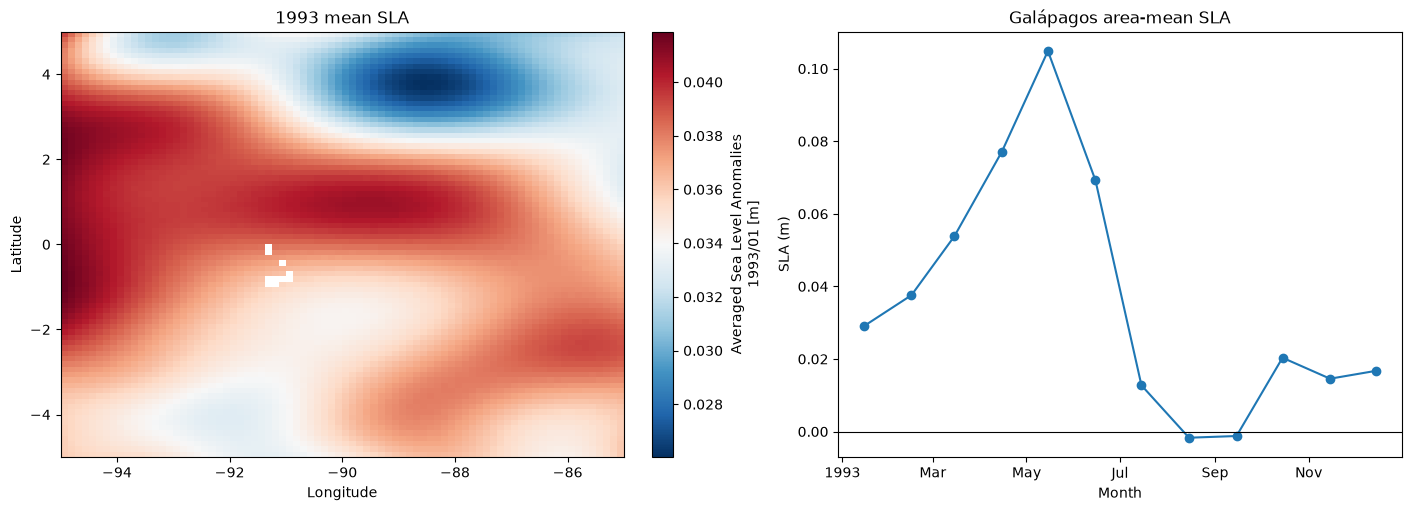

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

OUTPUT_FILE = Path("data/sla_galapagos/sla_galapagos_monthly_1993.nc")
if not OUTPUT_FILE.exists():
    OUTPUT_FILE = Path("../data/sla_galapagos/sla_galapagos_monthly_1993.nc")

with xr.open_dataset(OUTPUT_FILE) as dataset:
    sla = dataset["sla"]
    latitude = "latitude" if "latitude" in sla.dims else "lat"
    longitude = "longitude" if "longitude" in sla.dims else "lon"

    print(dataset)
    print(f"SLA range: {float(sla.min()):.4f} to {float(sla.max()):.4f} m")

    spatial_mean = sla.mean(dim="time")
    area_mean = sla.mean(dim=[latitude, longitude])

    figure, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    spatial_mean.plot(ax=axes[0], cmap="RdBu_r")
    axes[0].set_title("1993 mean SLA")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    area_mean.plot(ax=axes[1], marker="o")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Galápagos area-mean SLA")
    axes[1].set_ylabel("SLA (m)")
    axes[1].set_xlabel("Month")

    plt.show()

In [5]:
import math

TARGET_LATITUDE = -(1 + 20 / 60**2)
TARGET_LONGITUDE = -(91 + 4 / 60 + 49.2 / 3600)

with xr.open_dataset(OUTPUT_FILE) as dataset:
    sla = dataset["sla"]
    latitude = "latitude" if "latitude" in sla.dims else "lat"
    longitude = "longitude" if "longitude" in sla.dims else "lon"

    nearest = sla.sel(
        {latitude: TARGET_LATITUDE, longitude: TARGET_LONGITUDE},
        method="nearest",
    )

    selected_latitude = float(nearest[latitude])
    selected_longitude = float(nearest[longitude])
    latitude_distance = abs(selected_latitude - TARGET_LATITUDE)
    longitude_distance = abs(selected_longitude - TARGET_LONGITUDE)

    latitude_size_m = 0.125 * 111_320
    longitude_size_m = latitude_size_m * math.cos(math.radians(abs(TARGET_LATITUDE)))

    print(f"Target: {TARGET_LATITUDE:.6f}°, {TARGET_LONGITUDE:.6f}°")
    print(f"Nearest cell center: {selected_latitude:.6f}°, {selected_longitude:.6f}°")
    print(f"Coordinate offset: {latitude_distance:.6f}° latitude, {longitude_distance:.6f}° longitude")
    print(f"Nearest-cell SLA shape: {nearest.sizes}")
    print(f"Cell size near Quinta Playa: approximately {latitude_size_m / 1000:.2f} km north-south by {longitude_size_m / 1000:.2f} km east-west")
    print(f"Approximate cell area: {latitude_size_m * longitude_size_m / 1_000_000:.1f} km²")

Target: -1.005556°, -91.080333°
Nearest cell center: -1.062500°, -91.062500°
Coordinate offset: 0.056944° latitude, 0.017833° longitude
Nearest-cell SLA shape: Frozen({'time': 12})
Cell size near Quinta Playa: approximately 13.91 km north-south by 13.91 km east-west
Approximate cell area: 193.6 km²


In [7]:
from pathlib import Path

import pandas as pd
import xarray as xr

INPUT_DIR = Path("data/sla_monthly_downloads")
if not INPUT_DIR.exists():
    INPUT_DIR = Path("../data/sla_monthly_downloads")

OUTPUT_DIR = INPUT_DIR.parent / "quinta_playa_sla"
NETCDF_FILE = OUTPUT_DIR / "quinta_playa_sla_monthly.nc"
EXCEL_FILE = OUTPUT_DIR / "quinta_playa_sla_monthly.xlsx"
monthly_files = sorted(INPUT_DIR.glob("dt_global_allsat_msla_h_y*_m*.nc"))

if not monthly_files:
    raise FileNotFoundError(f"No monthly NetCDF files found in {INPUT_DIR}")

with xr.open_mfdataset(
    monthly_files,
    combine="by_coords",
    data_vars="minimal",
    coords="minimal",
    compat="override",
) as dataset:
    if "sla" not in dataset.data_vars:
        raise ValueError(f"Expected an 'sla' variable; found {list(dataset.data_vars)}")

    latitude = "latitude" if "latitude" in dataset.coords else "lat"
    longitude = "longitude" if "longitude" in dataset.coords else "lon"

    quinta_playa_sla = dataset["sla"].sel(
        {latitude: TARGET_LATITUDE, longitude: TARGET_LONGITUDE},
        method="nearest",
    ).load()

    selected_latitude = float(quinta_playa_sla[latitude])
    selected_longitude = float(quinta_playa_sla[longitude])
    output_dataset = quinta_playa_sla.to_dataset(name="sla")

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_dataset.to_netcdf(NETCDF_FILE)

    table = output_dataset.to_dataframe().reset_index()
    table.to_excel(EXCEL_FILE, index=False, sheet_name="SLA")

print(f"Processed {len(monthly_files)} monthly files")
print(f"Selected cell center: {selected_latitude:.6f}°, {selected_longitude:.6f}°")
print(f"Output dimensions: {dict(output_dataset.sizes)}")
print(f"Saved NetCDF: {NETCDF_FILE}")
print(f"Saved Excel: {EXCEL_FILE}")

Processed 396 monthly files
Selected cell center: -1.062500°, -91.062500°
Output dimensions: {'time': 396}
Saved NetCDF: ..\data\quinta_playa_sla\quinta_playa_sla_monthly.nc
Saved Excel: ..\data\quinta_playa_sla\quinta_playa_sla_monthly.xlsx


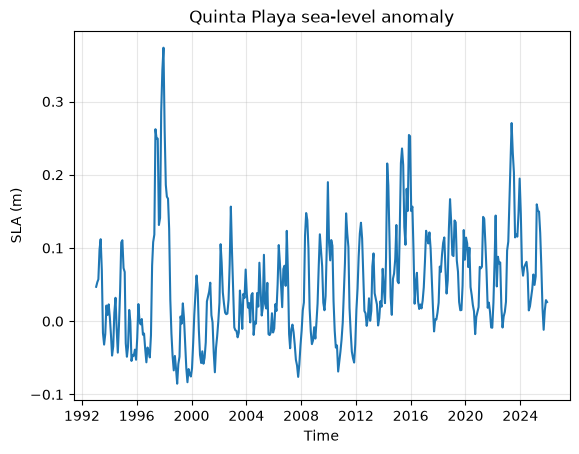

In [11]:
import matplotlib.pyplot as plt
import xarray as xr

with xr.open_dataset(NETCDF_FILE) as dataset:
    dataset["sla"].plot(marker="")
    plt.xlabel("Time")
    plt.ylabel("SLA (m)")
    plt.title("Quinta Playa sea-level anomaly")
    plt.grid(True, alpha=0.3)
    plt.show()

MEI v2: 1993-01 to 2025-12 (396 months)
Niño 1+2: 1993-01 to 2025-12 (396 months)
Niño 3.4: 1993-01 to 1994-07 (19 months)


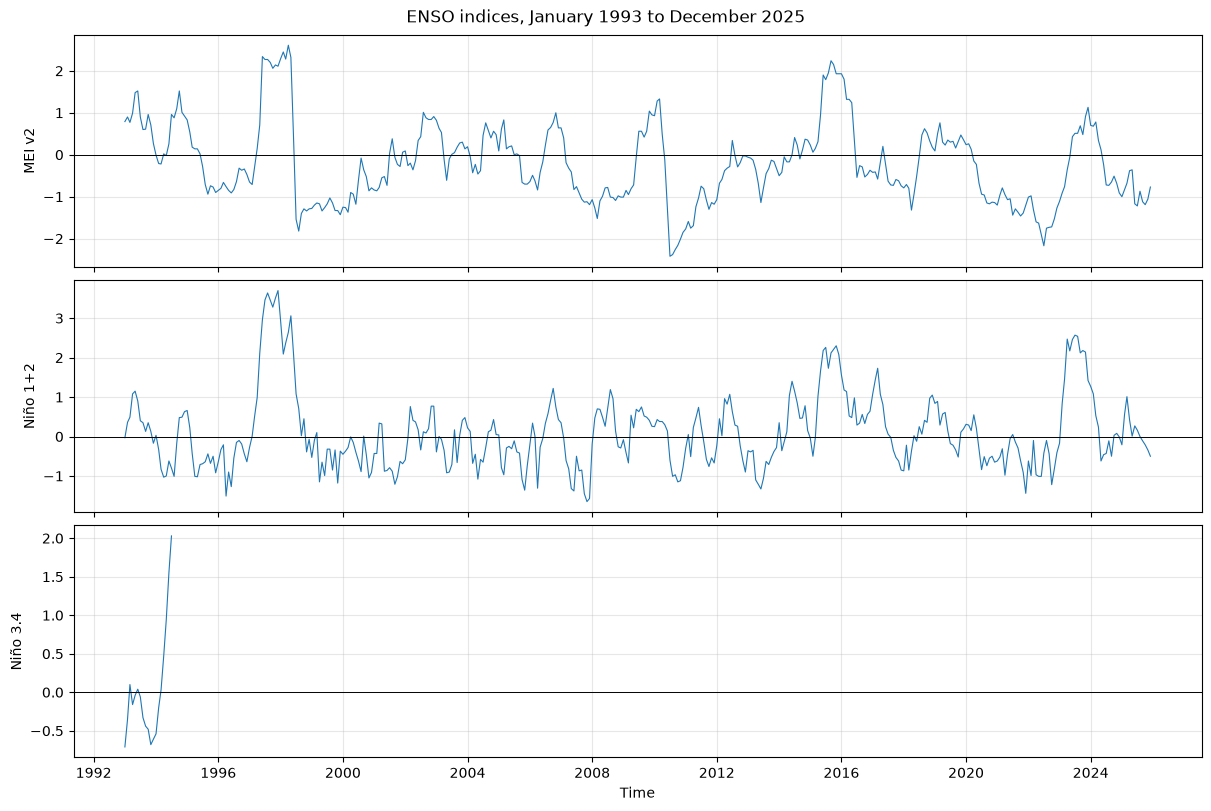

Aligned shape: (396, 3)
Missing values by index:
MEI v2        0
Niño 1+2      0
Niño 3.4    377
dtype: int64


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

DATA_DIR = Path("data/el nino")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data/el nino")

FILES = {
    "MEI v2": DATA_DIR / "meiv2.nc",
    "Niño 1+2": DATA_DIR / "nina1.anom.nc",
    "Niño 3.4": DATA_DIR / "nina34.anom.nc",
}

START = "1993-01-01"
END = "2025-12-01"
TARGET_TIME = pd.date_range(START, END, freq="MS")


def load_monthly_index(path):
    with xr.open_dataset(path) as dataset:
        time_variables = [
            name for name, variable in dataset.data_vars.items()
            if "time" in variable.dims
        ]
        if not time_variables:
            raise ValueError(f"No time-varying data variable found in {path.name}")

        values = dataset[time_variables[0]].squeeze(drop=True).load()

    if values.ndim != 1:
        raise ValueError(
            f"Expected one-dimensional index in {path.name}; found dimensions {values.dims}"
        )

    series = values.to_series()
    series.index = pd.to_datetime(series.index)
    series = series.groupby(series.index.to_period("M")).mean()
    series.index = series.index.to_timestamp()
    return series.reindex(TARGET_TIME)


indices = pd.DataFrame({name: load_monthly_index(path) for name, path in FILES.items()})
indices.index.name = "time"

for name in indices.columns:
    available = indices[name].dropna()
    if available.empty:
        print(f"{name}: no data in the requested period")
    else:
        print(
            f"{name}: {available.index[0]:%Y-%m} to "
            f"{available.index[-1]:%Y-%m} ({len(available)} months)"
        )

figure, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
for axis, name in zip(axes, indices.columns):
    axis.plot(indices[name].dropna(), linewidth=0.8)
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_ylabel(name)
    axis.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
figure.suptitle("ENSO indices, January 1993 to December 2025")
plt.show()

print(f"Aligned shape: {indices.shape}")
print(f"Missing values by index:\n{indices.isna().sum()}")